In [68]:
import time, warnings, re
from pathlib import Path
import numpy as np
import pandas as pd
import requests
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import missingno as msno
from IPython.display import display

# Plotting defaults and colour palette
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.05, palette="muted")
plt.rcParams["figure.dpi"]    = 120
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", "{:.2f}".format)

NAVY, STEEL, CORAL, GREEN, BLACK, RED, GOLD, LIGHTBLUE, BROWN, ROSE = \
    "#1A3764", "#4682B4", "#E8735A", "#27AE60", "#000000", \
    "#E74C3C", "#F1C40F", "#A2D2FF", "#8B4513", "#FF69B4"
PALETTE = [NAVY, STEEL, CORAL, GREEN, BLACK, RED, GOLD, LIGHTBLUE, BROWN, ROSE]

In [69]:
import os, requests

AI_ADOPTION_PATH = "data/AI_adoption_in_EU_enterprises.csv"
AI_NACE_PATH     = "data/AI_by_NACE.csv"

AI_ADOPTION_URL = ("https://ec.europa.eu/eurostat/api/dissemination/sdmx/3.0/data/"
                   "dataflow/ESTAT/isoc_eb_ai/1.0?compress=false&format=csvdata"
                   "&formatVersion=2.0&lang=en&labels=name")
AI_NACE_URL     = ("https://ec.europa.eu/eurostat/api/dissemination/sdmx/3.0/data/"
                   "dataflow/ESTAT/isoc_eb_ain2/1.0?compress=false&format=csvdata"
                   "&formatVersion=2.0&lang=en&labels=name")

os.makedirs("data", exist_ok=True)

def download_if_missing(path, url):
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / 1e6
        print(f"  ✓ {path} already present ({size_mb:.0f} MB) — skipping download")
    else:
        print(f"  ↓ Downloading {path} …")
        with open(path, "wb") as f:
            f.write(requests.get(url).content)
        print(f"    Done ({os.path.getsize(path)/1e6:.0f} MB)")

download_if_missing(AI_ADOPTION_PATH, AI_ADOPTION_URL)
download_if_missing(AI_NACE_PATH,     AI_NACE_URL)

  ✓ data/AI_adoption_in_EU_enterprises.csv already present (34 MB) — skipping download
  ✓ data/AI_by_NACE.csv already present (285 MB) — skipping download


In [70]:
# Colour constants used by all charts
BG       = "#f8f9fa"
C_NAVY   = "#1A3764"
C_STEEL  = "#4682B4"
C_CORAL  = "#E8735A"
C_GREEN  = "#27AE60"
C_BLACK  = "#000000"
C_RED    = "#E74C3C"
C_GOLD   = "#F1C40F"
C_LIGHTBLUE = "#A2D2FF"
C_BROWN  = "#8B4513"
C_ROSE   = "#FF69B4"
C_BLUE   = C_STEEL
C_ORANGE = C_CORAL
C_GREY   = "#cccccc"

In [71]:
# Configuration

EU27 = [
    'Belgium', 'Bulgaria', 'Czechia', 'Denmark', 'Germany', 'Estonia',
    'Ireland', 'Greece', 'Spain', 'France', 'Croatia', 'Italy', 'Cyprus',
    'Latvia', 'Lithuania', 'Luxembourg', 'Hungary', 'Malta', 'Netherlands',
    'Austria', 'Poland', 'Portugal', 'Romania', 'Slovenia', 'Slovakia',
    'Finland', 'Sweden'
]

In [72]:
print("Loading real Eurostat data from Eurostat CSVs …")

USE_AI   = ("Enterprises using at least one of the AI technologies: "
            "AI_TTM, AI_TSR, AI_TNLG, AI_TIR, AI_TML, AI_TPA, AI_TAR, E_AI_TPVSG")
ALL_NACE = ("All activities (except agriculture, forestry and fishing, "
            "and mining and quarrying), without financial sector")

SIZE_COL  = "Size classes in number of persons employed"
INDIC_COL = "Information society indicator"
GEO_COL   = "Geopolitical entity (reporting)"
NACE_COL  = "Statistical classification of economic activities in the European Community (NACE Rev. 2)"
UNIT_COL  = "Unit of measure"
YR_COL    = "TIME_PERIOD"
VAL_COL   = "OBS_VALUE"

SIZE_MAP = {
    "From 10 to 49 persons employed": "Small (10-49)",
    "10 persons employed or more":    "All (10+)",
    "250 persons employed or more":   "Large (250+)",
}

SECTOR_MAP = {
    ALL_NACE:                                                                       "All activities",
    "Manufacturing":                                                                "Manufacturing",
    "Information and communication":                                                "Information & Communication",
    "Construction":                                                                 "Construction",
    "Transportation and storage":                                                   "Transportation & Storage",
    "Professional, scientific and technical activities":                            "Professional & Scientific",
    "Wholesale and retail trade; repair of motor vehicles and motorcycles":         "Wholesale & Retail Trade",
    "Accommodation and food service activities":                                    "Accommodation & Food",
}

# ── Size data (isoc_eb_ai) ───────────────────────────────────────────────────
df_ai = pd.read_csv("data/AI_adoption_in_EU_enterprises.csv", low_memory=False)

mask_size = (
    (df_ai[INDIC_COL] == USE_AI) &
    (df_ai[NACE_COL]  == ALL_NACE) &
    (df_ai[UNIT_COL]  == "Percentage of enterprises") &
    (df_ai[SIZE_COL].isin(SIZE_MAP)) &
    (df_ai[GEO_COL].isin(EU27))
)
df_size = df_ai[mask_size][[SIZE_COL, GEO_COL, YR_COL, VAL_COL]].copy()
df_size["size"]  = df_size[SIZE_COL].map(SIZE_MAP)
df_size = df_size.rename(columns={GEO_COL: "country", YR_COL: "yr", VAL_COL: "value"})
df_size["yr"]    = df_size["yr"].astype(int)
df_size["value"] = pd.to_numeric(df_size["value"], errors="coerce")
df_size = df_size[["country", "yr", "size", "value"]].dropna()

# ── Sector data (isoc_eb_ain2) ───────────────────────────────────────────────
df_nace = pd.read_csv("data/AI_by_NACE.csv", low_memory=False)

mask_sector = (
    (df_nace[INDIC_COL] == USE_AI) &
    (df_nace[UNIT_COL]  == "Percentage of enterprises") &
    (df_nace[SIZE_COL]  == "10 persons employed or more") &
    (df_nace[NACE_COL].isin(SECTOR_MAP)) &
    (df_nace[GEO_COL].isin(EU27))
)
df_sector = df_nace[mask_sector][[NACE_COL, GEO_COL, YR_COL, VAL_COL]].copy()
df_sector["sector"] = df_sector[NACE_COL].map(SECTOR_MAP)
df_sector = df_sector.rename(columns={GEO_COL: "country", YR_COL: "yr", VAL_COL: "value"})
df_sector["yr"]    = df_sector["yr"].astype(int)
df_sector["value"] = pd.to_numeric(df_sector["value"], errors="coerce")
df_sector = df_sector[["country", "yr", "sector", "value"]].dropna()

# ── 2025 slices used by charts ───────────────────────────────────────────────
all25   = df_size[(df_size["size"] == "All (10+)")    & (df_size["yr"] == 2025)].set_index("country")["value"]
small25 = df_size[(df_size["size"] == "Small (10-49)")& (df_size["yr"] == 2025)].set_index("country")["value"]
large25 = df_size[(df_size["size"] == "Large (250+)") & (df_size["yr"] == 2025)].set_index("country")["value"]

EU27_ORDER_2025 = all25.sort_values(ascending=True).index.tolist()

print(f"Size data  : {df_size.shape[0]:,} rows | years: {sorted(df_size['yr'].unique())}")
print(f"Sector data: {df_sector.shape[0]:,} rows | sectors: {df_sector['sector'].nunique()}")
print("Data loading complete! ✓")

Loading real Eurostat data from Eurostat CSVs …
Size data  : 324 rows | years: [np.int64(2021), np.int64(2023), np.int64(2024), np.int64(2025)]
Sector data: 857 rows | sectors: 8
Data loading complete! ✓


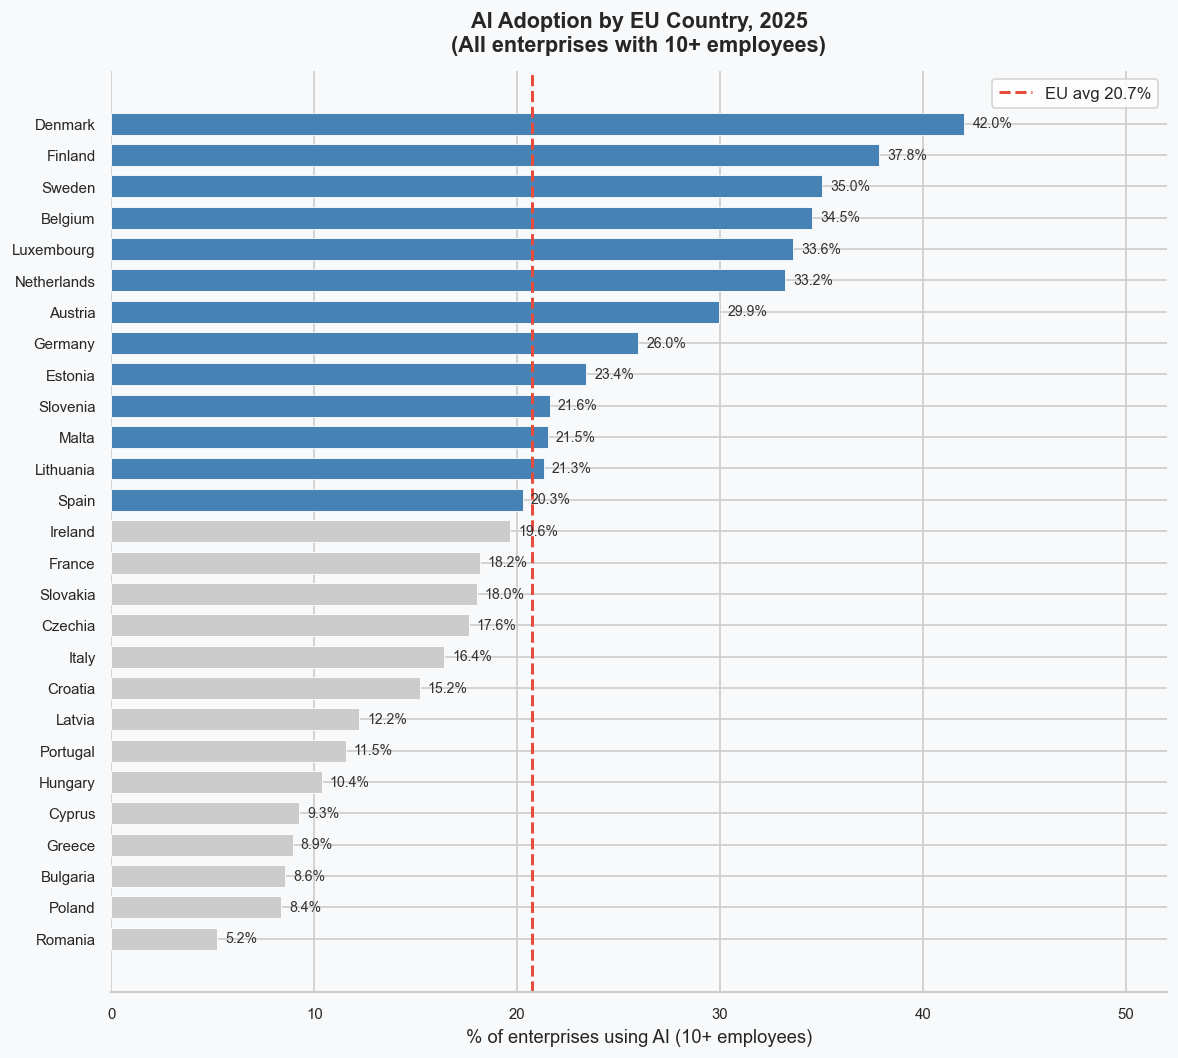

In [73]:
# ── Chart 1 — AI adoption by country (all firms, 2025) ───────────────────────
fig, ax = plt.subplots(figsize=(10, 9), facecolor=BG)
ax.set_facecolor(BG)

sub    = all25.reindex(EU27_ORDER_2025)
colors = [C_BLUE if v >= 20 else C_GREY for v in sub]
ax.barh(sub.index, sub.values, color=colors, edgecolor='white', linewidth=0.5, height=0.7)

eu_avg = sub.mean()
ax.axvline(eu_avg, color=C_RED, lw=1.8, linestyle='--', label=f'EU avg {eu_avg:.1f}%')

for i, (country, val) in enumerate(sub.items()):
    ax.text(val + 0.4, i, f'{val:.1f}%', va='center', fontsize=8.5, color='#333333')

ax.set_xlabel('% of enterprises using AI (10+ employees)', fontsize=11)
ax.set_title('AI Adoption by EU Country, 2025\n(All enterprises with 10+ employees)',
             fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=10)
ax.set_xlim(0, 52)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(axis='both', labelsize=9)
plt.tight_layout()
plt.show()

Building Chart 2 …


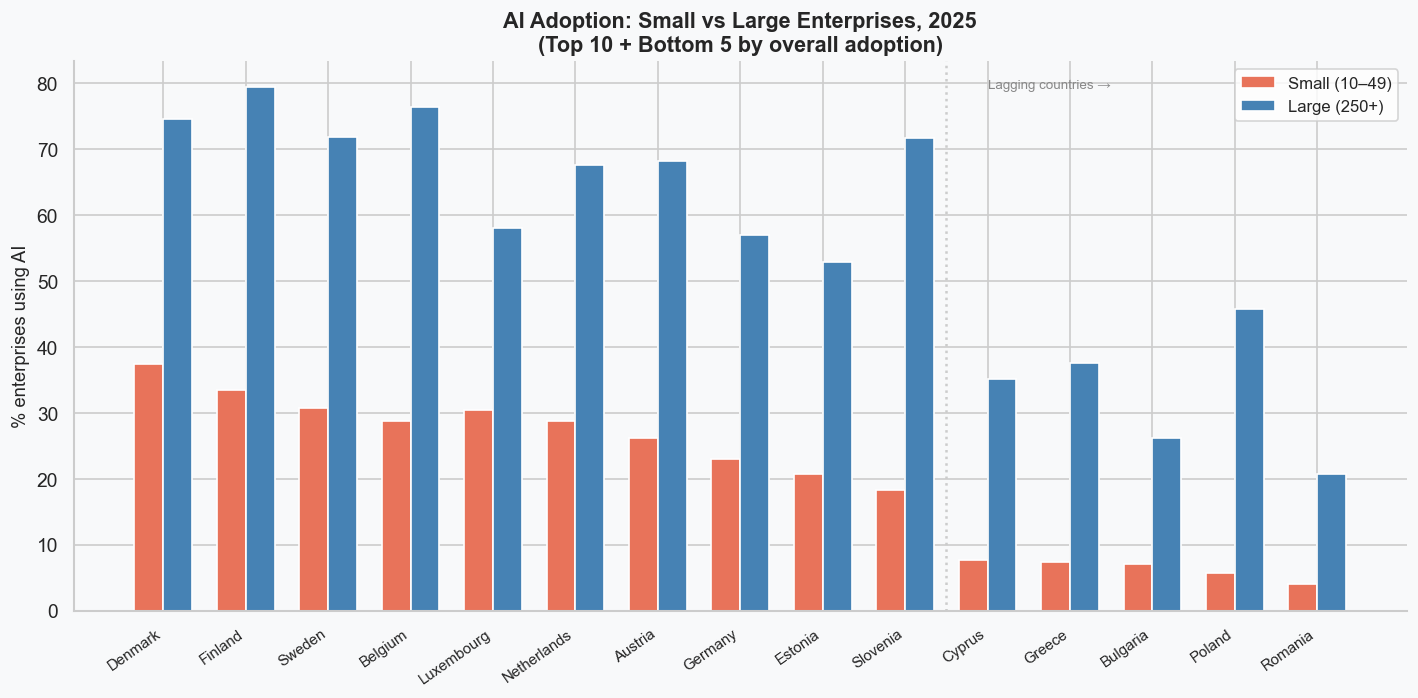

In [74]:
# ── Chart 2 — Small vs Large: top 10 + bottom 5 countries ───────────────────
print("Building Chart 2 …")
sel = (all25.sort_values(ascending=False).head(10).index.tolist() +
       all25.sort_values(ascending=False).tail(5).index.tolist())

fig, ax = plt.subplots(figsize=(12, 6), facecolor=BG)
ax.set_facecolor(BG)

x, w = np.arange(len(sel)), 0.35
ax.bar(x - w/2, [small25.get(c, np.nan) for c in sel], w,
       label='Small (10–49)', color=C_ORANGE, edgecolor='white')
ax.bar(x + w/2, [large25.get(c, np.nan) for c in sel], w,
       label='Large (250+)',  color=C_BLUE,   edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(sel, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('% enterprises using AI', fontsize=11)
ax.set_title('AI Adoption: Small vs Large Enterprises, 2025\n(Top 10 + Bottom 5 by overall adoption)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.axvline(9.5, color='#cccccc', lw=1.5, linestyle=':')
ax.text(10, ax.get_ylim()[1] * 0.95, 'Lagging countries →', fontsize=8, color='#888888')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

Building Chart 3 …


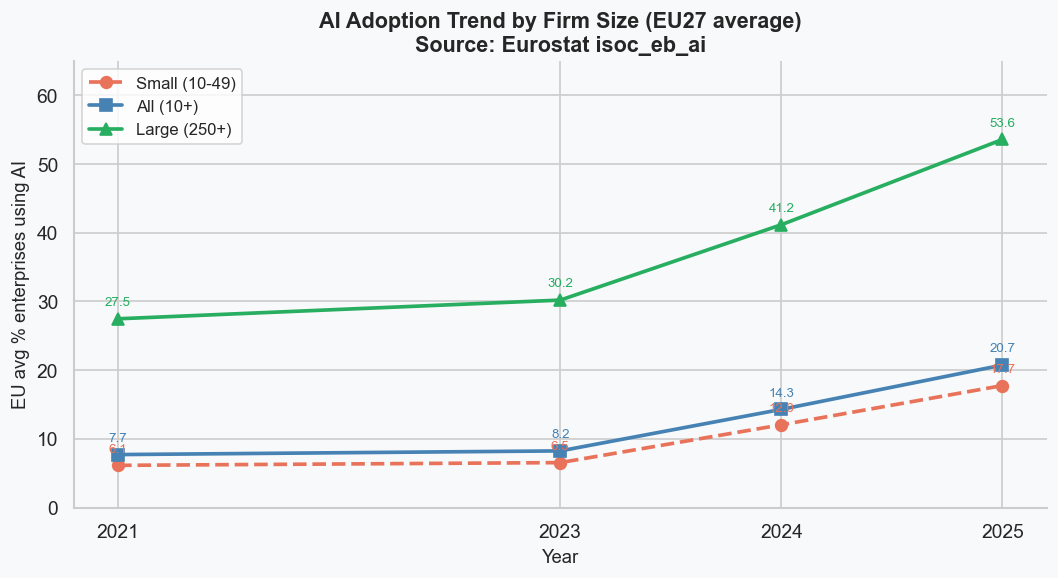

In [75]:
# ── Chart 3 — Time trend: EU avg by size class (2021–2025) ──────────────────
print("Building Chart 3 …")
fig, ax = plt.subplots(figsize=(9, 5), facecolor=BG)
ax.set_facecolor(BG)

styles = {
    'Small (10-49)': (C_ORANGE, 'o', '--'),
    'All (10+)':     (C_BLUE,   's', '-'),
    'Large (250+)':  (C_GREEN,  '^', '-'),
}
for size, (col, marker, ls) in styles.items():
    trend = df_size[df_size['size'] == size].groupby('yr')['value'].mean().sort_index()
    ax.plot(trend.index, trend.values, color=col, marker=marker, linestyle=ls,
            linewidth=2.2, markersize=7, label=size)
    for yr, val in trend.items():
        ax.annotate(f'{val:.1f}', (yr, val), textcoords='offset points',
                    xytext=(0, 8), ha='center', fontsize=8, color=col)

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('EU avg % enterprises using AI', fontsize=11)
ax.set_title('AI Adoption Trend by Firm Size (EU27 average)\nSource: Eurostat isoc_eb_ai', fontsize=13, fontweight='bold')
ax.set_xticks(sorted(df_size['yr'].unique()))
ax.legend(fontsize=10)
ax.set_ylim(0, 65)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

Building Chart 4 …


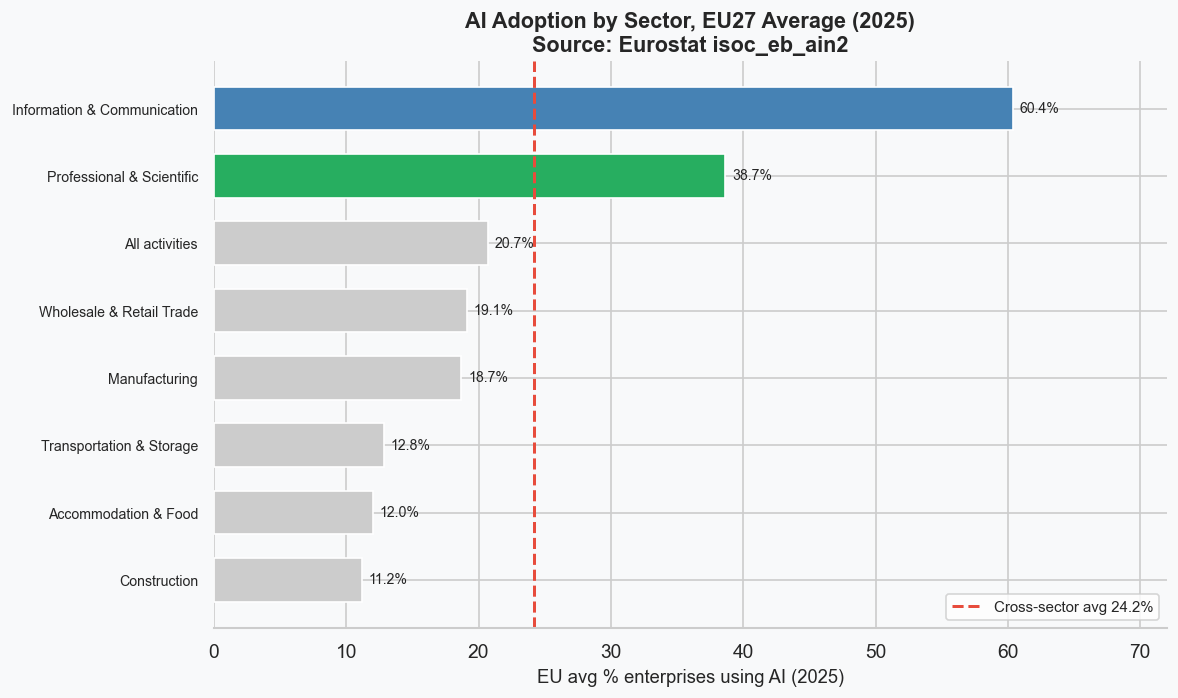

In [76]:
# ── Chart 4 — Sector comparison (EU avg 2025) ────────────────────────────────
print("Building Chart 4 …")

sector_data = (
    df_sector[df_sector["yr"] == 2025]
    .groupby("sector")["value"]
    .mean()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG)
ax.set_facecolor(BG)
colors_s = [C_BLUE if 'Information' in k else (C_GREEN if v >= sector_data.mean() else C_GREY)
            for k, v in sector_data.items()]
ax.barh(sector_data.index, sector_data.values, color=colors_s, edgecolor='white', height=0.65)
ax.axvline(sector_data.mean(), color=C_RED, lw=1.8, linestyle='--',
           label=f'Cross-sector avg {sector_data.mean():.1f}%')
for i, (k, v) in enumerate(sector_data.items()):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=8.5)
ax.set_xlabel('EU avg % enterprises using AI (2025)', fontsize=11)
ax.set_title('AI Adoption by Sector, EU27 Average (2025)\nSource: Eurostat isoc_eb_ain2', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(0, 72)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(axis='y', labelsize=8.5)
plt.tight_layout()
plt.show()

Building Chart 5 …


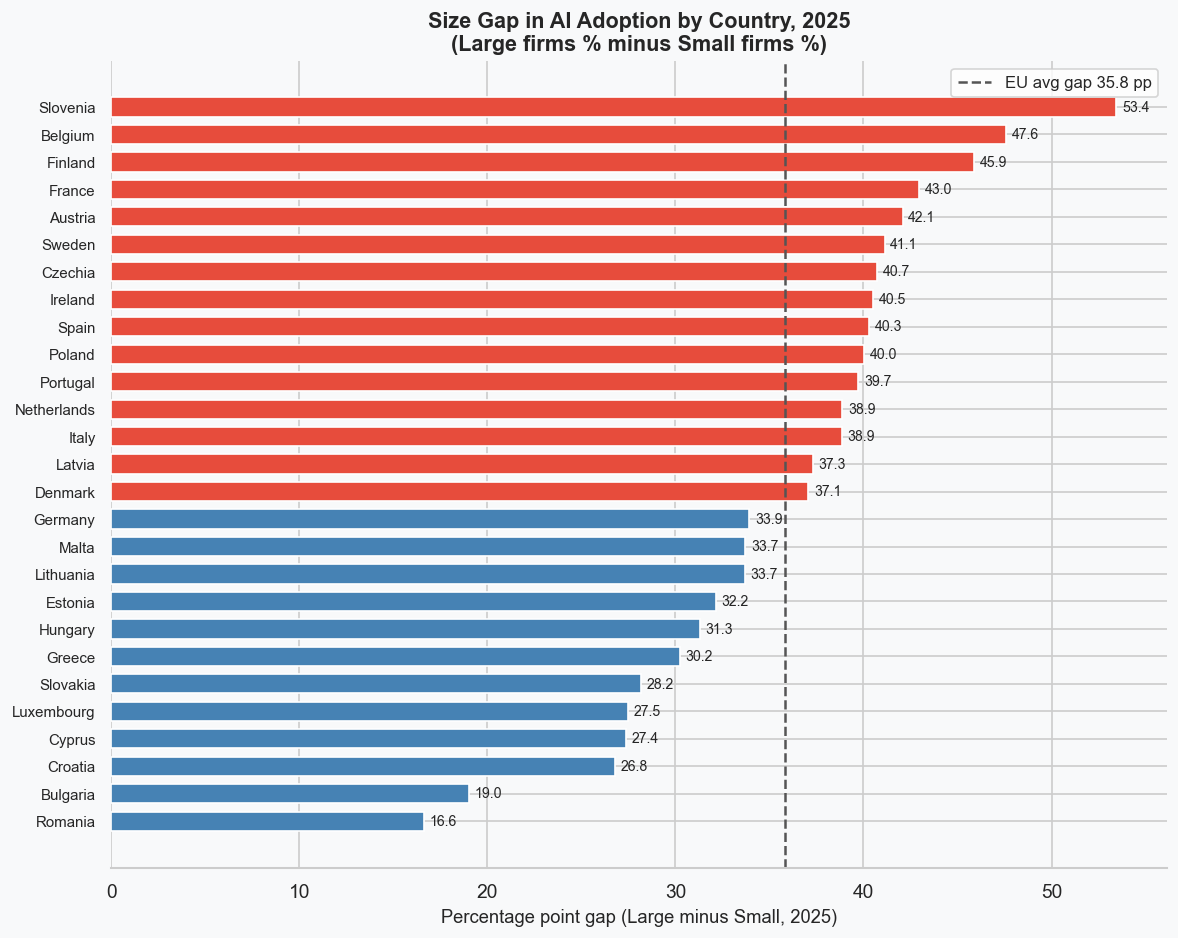

In [77]:
# ── Chart 5 — Size gap (large minus small) per country ───────────────────────
print("Building Chart 5 …")
gap = (large25 - small25).dropna().sort_values()

fig, ax = plt.subplots(figsize=(10, 8), facecolor=BG)
ax.set_facecolor(BG)
cols_gap = [C_BLUE if v < gap.mean() else C_RED for v in gap]
ax.barh(gap.index, gap.values, color=cols_gap, edgecolor='white', height=0.7)
ax.axvline(gap.mean(), color='#555555', lw=1.5, linestyle='--',
           label=f'EU avg gap {gap.mean():.1f} pp')
for i, (k, v) in enumerate(gap.items()):
    ax.text(v + 0.3, i, f'{v:.1f}', va='center', fontsize=8.5)
ax.set_xlabel('Percentage point gap (Large minus Small, 2025)', fontsize=11)
ax.set_title('Size Gap in AI Adoption by Country, 2025\n(Large firms % minus Small firms %)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.show()

In [78]:
# ── Save clean CSVs (real Eurostat data) ─────────────────────────────────────
df_size.to_csv('ai_by_size.csv', index=False)
df_sector.to_csv('ai_by_sector.csv', index=False)
print(f"Saved ai_by_size.csv   ({df_size.shape[0]} rows)")
print(f"Saved ai_by_sector.csv ({df_sector.shape[0]} rows)")
print("\nAll done! ✓  —  Data source: Eurostat isoc_eb_ai / isoc_eb_ain2")

Saved ai_by_size.csv   (324 rows)
Saved ai_by_sector.csv (857 rows)

All done! ✓  —  Data source: Eurostat isoc_eb_ai / isoc_eb_ain2


# 2. Sector Analysis — AI Adoption Across Economic Activities (EU27, 2021–2025)

Eurostat data reveal that AI adoption is far from uniform across the economy. The aggregate figure — roughly one in five EU enterprises used AI in 2025 — conceals a striking structural divide: firms in Information & Communication adopt AI at a rate six times higher than those in Construction. This section maps that divide across all eight sectors, tracks its evolution over time, and tests whether the gap is narrowing or widening.

**Data source:** Eurostat `isoc_eb_ain2` — enterprises with 10 or more employees — EU27 countries — reference years 2021, 2023, 2024, 2025.

**Sections:**
- **S1** Sector ranking and distance from cross-sector average (2025)
- **S2** Adoption trend by sector, 2021–2025
- **S3** Within-sector country dispersion — how heterogeneous is each sector?
- **S4** Country × Sector heatmap — who leads and who lags in each activity?
- **S5** The ICT premium — how fast is the lead sector pulling away?
- **S6–S9** Deep dive: decomposing the gap, testing convergence, and zooming in on Italy

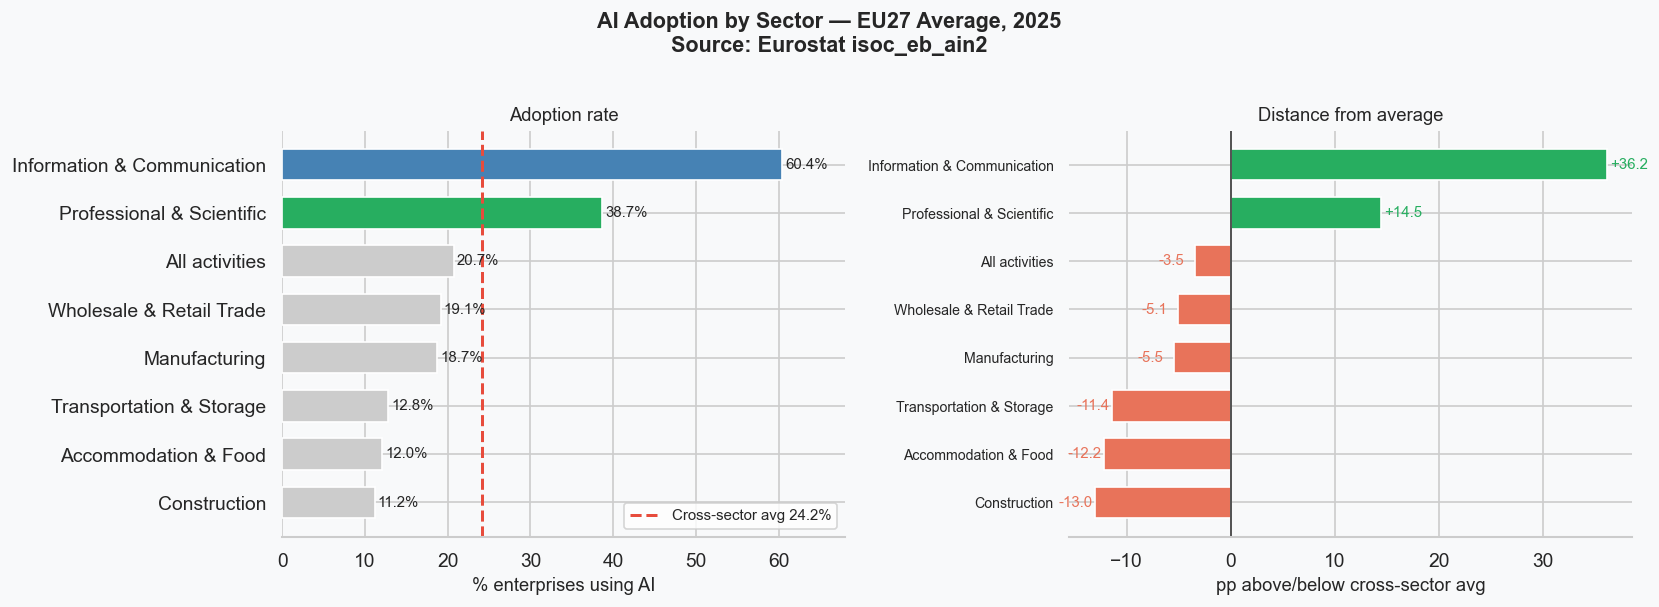


Cross-sector average (2025): 24.2%
Top sector   : Information & Communication (60.4%)
Bottom sector: Construction (11.2%)
Intersectoral gap (top − bottom): 49.2 pp


In [79]:
# ── S1 — Sector ranking 2025: EU avg + distance from cross-sector mean ────────
sec25 = df_sector[df_sector["yr"] == 2025].groupby("sector")["value"].mean().sort_values()
cross_avg = sec25.mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG)
fig.suptitle("AI Adoption by Sector — EU27 Average, 2025\nSource: Eurostat isoc_eb_ain2",
             fontsize=13, fontweight="bold", y=1.01)

# Left: absolute bar
ax = axes[0]
ax.set_facecolor(BG)
cols = [C_BLUE if "Information" in k else (C_GREEN if v >= cross_avg else C_GREY)
        for k, v in sec25.items()]
bars = ax.barh(sec25.index, sec25.values, color=cols, edgecolor="white", height=0.65)
ax.axvline(cross_avg, color=C_RED, lw=1.8, ls="--", label=f"Cross-sector avg {cross_avg:.1f}%")
for i, (k, v) in enumerate(sec25.items()):
    ax.text(v + 0.4, i, f"{v:.1f}%", va="center", fontsize=9)
ax.set_xlabel("% enterprises using AI", fontsize=11)
ax.set_title("Adoption rate", fontsize=11)
ax.legend(fontsize=9)
ax.set_xlim(0, 68)
ax.spines[["top", "right", "left"]].set_visible(False)

# Right: deviation from cross-sector mean
ax2 = axes[1]
ax2.set_facecolor(BG)
dev = (sec25 - cross_avg).sort_values()
cols2 = [C_GREEN if v >= 0 else C_CORAL for v in dev]
ax2.barh(dev.index, dev.values, color=cols2, edgecolor="white", height=0.65)
ax2.axvline(0, color="#555555", lw=1.2)
for i, (k, v) in enumerate(dev.items()):
    offset = 0.3 if v >= 0 else -3.5
    ax2.text(v + offset, i, f"{v:+.1f}", va="center", fontsize=9,
             color=C_GREEN if v >= 0 else C_CORAL)
ax2.set_xlabel("pp above/below cross-sector avg", fontsize=11)
ax2.set_title("Distance from average", fontsize=11)
ax2.spines[["top", "right", "left"]].set_visible(False)
ax2.tick_params(axis="y", labelsize=8.5)

plt.tight_layout()
plt.show()

print(f"\nCross-sector average (2025): {cross_avg:.1f}%")
print(f"Top sector   : {sec25.idxmax()} ({sec25.max():.1f}%)")
print(f"Bottom sector: {sec25.idxmin()} ({sec25.min():.1f}%)")
print(f"Intersectoral gap (top − bottom): {sec25.max() - sec25.min():.1f} pp")

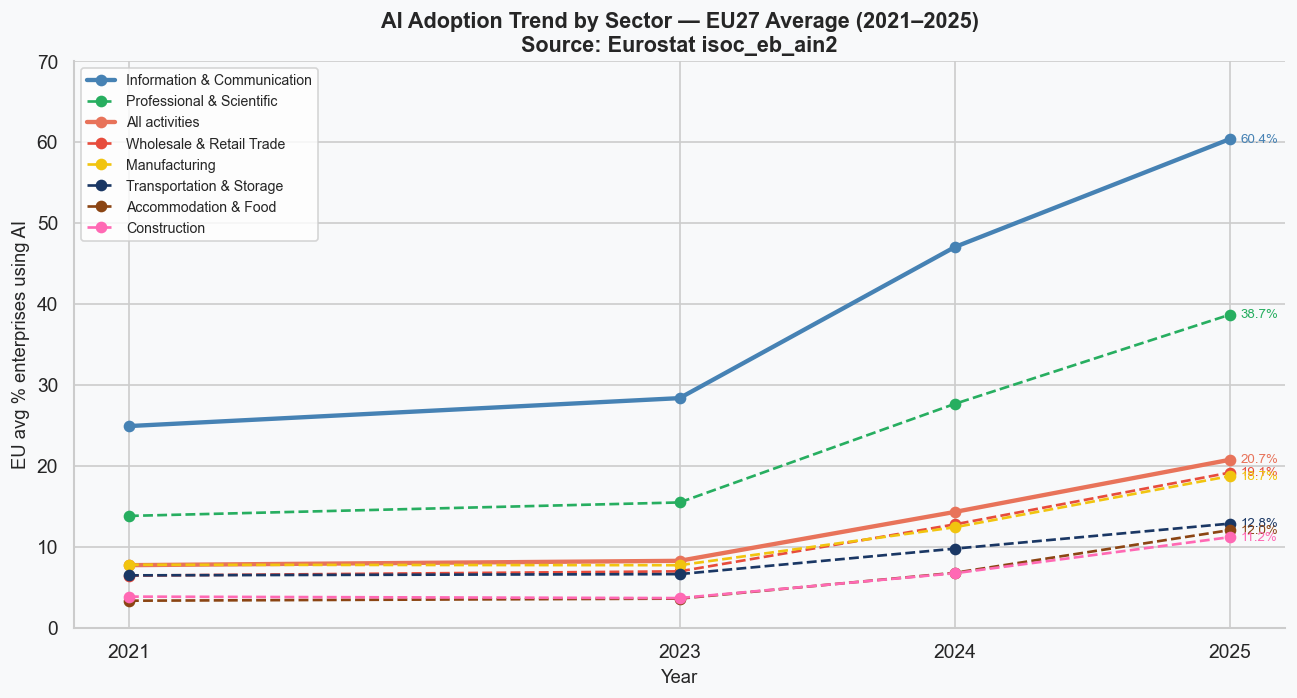


Growth by sector (2021 → 2025, percentage points):
  Information & Communication         24.9% → 60.4%   Δ +35.5 pp
  Professional & Scientific           13.8% → 38.7%   Δ +24.9 pp
  All activities                      7.7% → 20.7%   Δ +13.0 pp
  Wholesale & Retail Trade            6.4% → 19.1%   Δ +12.7 pp
  Manufacturing                       7.8% → 18.7%   Δ +11.0 pp
  Transportation & Storage            6.4% → 12.8%   Δ +6.4 pp
  Accommodation & Food                3.3% → 12.0%   Δ +8.7 pp
  Construction                        3.8% → 11.2%   Δ +7.4 pp


In [80]:
# ── S2 — Sector trend 2021 → 2025 ────────────────────────────────────────────
YEARS = [2021, 2023, 2024, 2025]

sector_order = (df_sector[df_sector["yr"] == 2025]
                .groupby("sector")["value"].mean()
                .sort_values(ascending=False).index.tolist())

palette = [C_BLUE, C_GREEN, C_ORANGE, C_RED, C_GOLD, C_NAVY, C_BROWN, C_ROSE]
color_map = {s: palette[i] for i, s in enumerate(sector_order)}

fig, ax = plt.subplots(figsize=(11, 6), facecolor=BG)
ax.set_facecolor(BG)

for sector in sector_order:
    trend = (df_sector[df_sector["sector"] == sector]
             .groupby("yr")["value"].mean()
             .reindex(YEARS))
    ls = "-" if "Information" in sector or "All" in sector else "--"
    lw = 2.6 if "Information" in sector or "All" in sector else 1.6
    ax.plot(trend.index, trend.values, color=color_map[sector],
            marker="o", markersize=6, linewidth=lw, linestyle=ls, label=sector)
    if not trend.isna().all():
        last_val = trend.dropna().iloc[-1]
        last_yr  = trend.dropna().index[-1]
        ax.annotate(f"{last_val:.1f}%", (last_yr, last_val),
                    textcoords="offset points", xytext=(6, 0),
                    fontsize=8, color=color_map[sector], va="center")

ax.set_xticks(YEARS)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("EU avg % enterprises using AI", fontsize=11)
ax.set_title("AI Adoption Trend by Sector — EU27 Average (2021–2025)\nSource: Eurostat isoc_eb_ain2",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=8.5, loc="upper left", framealpha=0.8)
ax.set_ylim(0, 70)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

# Growth table
print("\nGrowth by sector (2021 → 2025, percentage points):")
for sector in sector_order:
    sub = df_sector[df_sector["sector"] == sector].groupby("yr")["value"].mean()
    if 2021 in sub.index and 2025 in sub.index:
        growth = sub[2025] - sub[2021]
        print(f"  {sector:<35} {sub[2021]:.1f}% → {sub[2025]:.1f}%   Δ {growth:+.1f} pp")

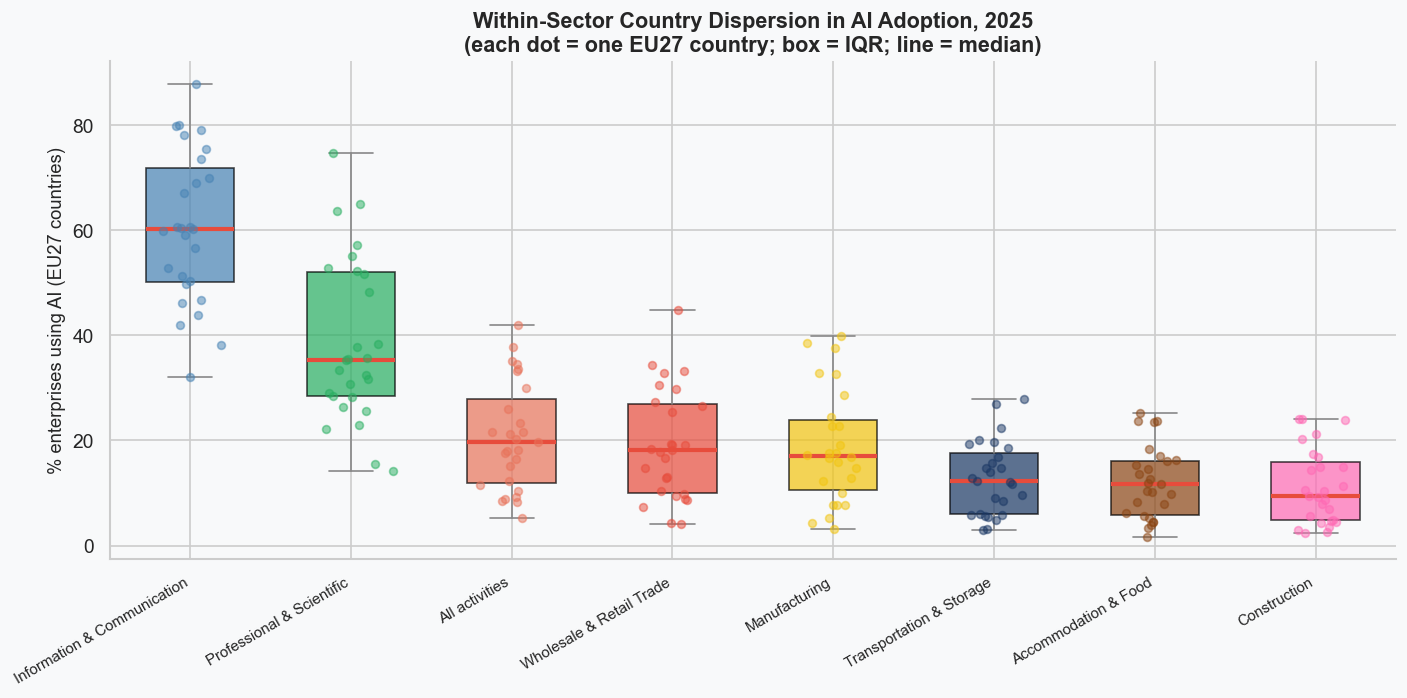


Within-sector dispersion (2025, EU27 countries):
Sector                               Median     IQR     Max     Min     Std
----------------------------------------------------------------------
Information & Communication           60.2%   21.7    87.9%   32.1%   14.5
Professional & Scientific             35.3%   23.6    74.8%   14.1%   15.6
All activities                        19.6%   16.1    42.0%    5.2%   10.3
Wholesale & Retail Trade              18.1%   16.8    44.8%    4.1%   10.4
Manufacturing                         17.0%   13.4    39.8%    3.2%   10.8
Transportation & Storage              12.2%   11.7    27.9%    3.0%    7.0
Accommodation & Food                  11.7%   10.3    25.2%    1.7%    6.9
Construction                           9.5%   11.0    24.0%    2.4%    7.1


In [81]:
# ── S3 — Within-sector country dispersion (box plot, 2025) ───────────────────
data_2025 = df_sector[df_sector["yr"] == 2025].copy()
sec_order_box = (data_2025.groupby("sector")["value"]
                 .median().sort_values(ascending=False).index.tolist())

fig, ax = plt.subplots(figsize=(12, 6), facecolor=BG)
ax.set_facecolor(BG)

bp = ax.boxplot(
    [data_2025[data_2025["sector"] == s]["value"].dropna().values for s in sec_order_box],
    vert=True, patch_artist=True, widths=0.55,
    medianprops=dict(color=C_RED, linewidth=2.5),
    whiskerprops=dict(color="#888888"),
    capprops=dict(color="#888888"),
    flierprops=dict(marker="o", markersize=5, alpha=0.5, markerfacecolor=C_CORAL),
)
for patch, sector in zip(bp["boxes"], sec_order_box):
    patch.set_facecolor(color_map.get(sector, C_GREY))
    patch.set_alpha(0.7)

# overlay individual country dots
for i, sector in enumerate(sec_order_box, start=1):
    vals = data_2025[data_2025["sector"] == sector]["value"].dropna()
    ax.scatter(np.random.normal(i, 0.08, size=len(vals)), vals,
               color=color_map.get(sector, C_GREY), alpha=0.5, s=22, zorder=3)

ax.set_xticks(range(1, len(sec_order_box) + 1))
ax.set_xticklabels(sec_order_box, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("% enterprises using AI (EU27 countries)", fontsize=11)
ax.set_title("Within-Sector Country Dispersion in AI Adoption, 2025\n"
             "(each dot = one EU27 country; box = IQR; line = median)",
             fontsize=13, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

# Dispersion statistics
print("\nWithin-sector dispersion (2025, EU27 countries):")
print(f"{'Sector':<35} {'Median':>7} {'IQR':>7} {'Max':>7} {'Min':>7} {'Std':>7}")
print("-" * 70)
for s in sec_order_box:
    v = data_2025[data_2025["sector"] == s]["value"].dropna()
    iqr = v.quantile(0.75) - v.quantile(0.25)
    print(f"{s:<35} {v.median():>6.1f}% {iqr:>6.1f}  {v.max():>6.1f}% {v.min():>6.1f}% {v.std():>6.1f}")

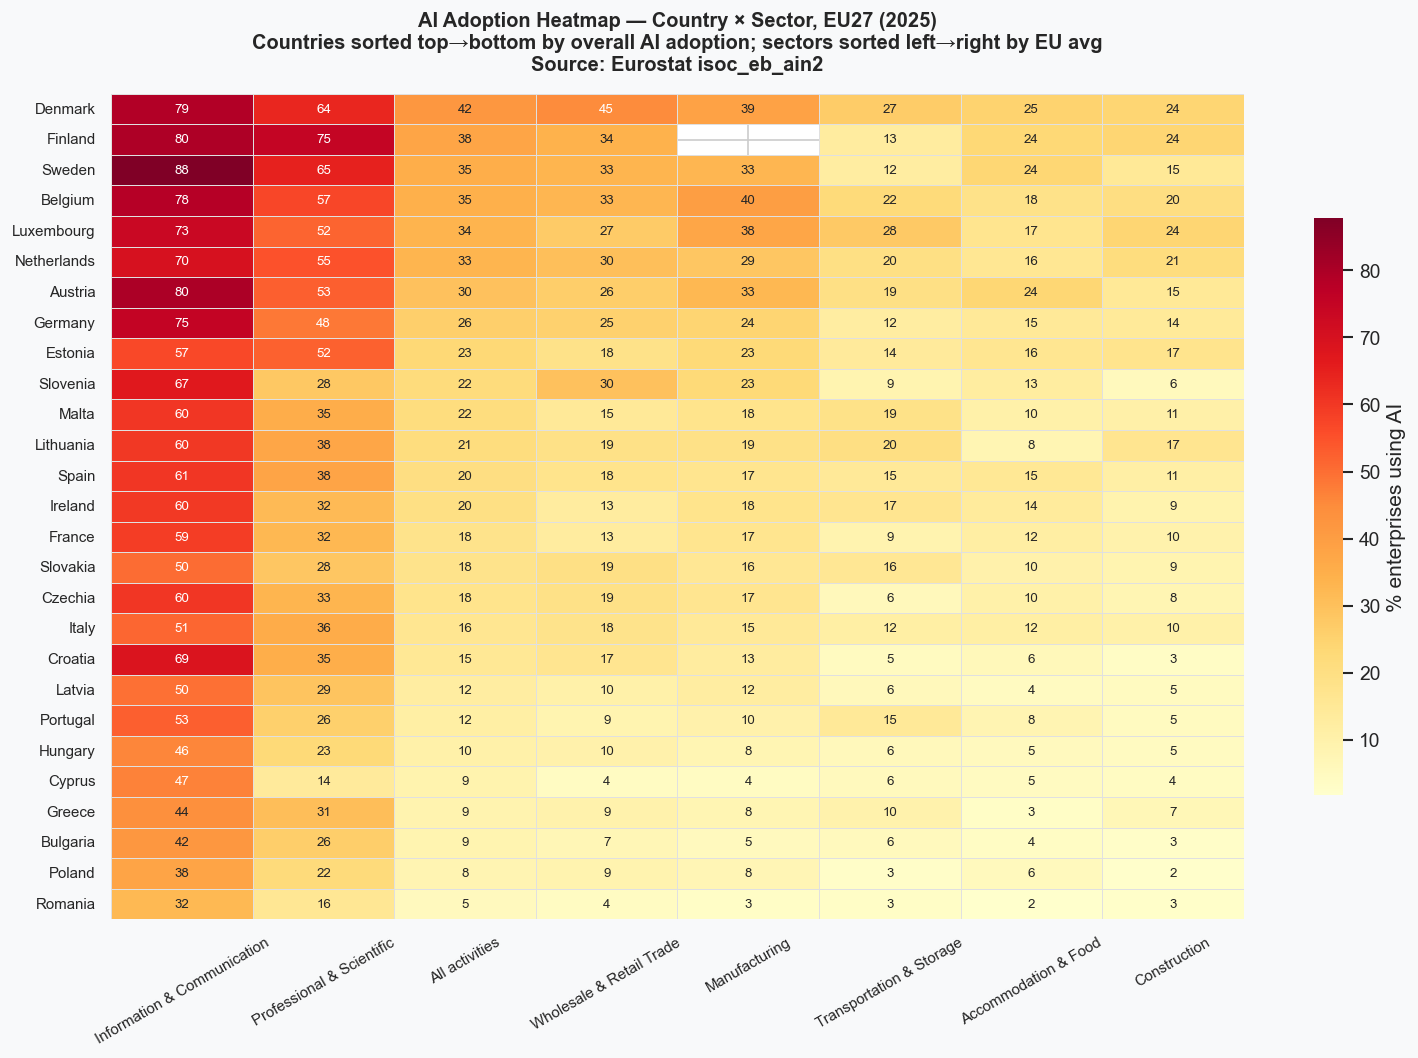

In [82]:
# ── S4 — Heatmap: Country × Sector (2025) ────────────────────────────────────
pivot = (df_sector[df_sector["yr"] == 2025]
         .pivot_table(index="country", columns="sector", values="value", aggfunc="mean"))

# order: countries by overall AI adoption (all25), sectors by EU avg
country_order = all25.sort_values(ascending=False).index.tolist()
pivot = pivot.reindex(country_order)
pivot = pivot[sec25.sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(13, 9), facecolor=BG)
sns.heatmap(
    pivot, ax=ax, cmap="YlOrRd", annot=True, fmt=".0f",
    linewidths=0.4, linecolor="#e0e0e0",
    cbar_kws={"label": "% enterprises using AI", "shrink": 0.7},
    annot_kws={"size": 8},
)
ax.set_title("AI Adoption Heatmap — Country × Sector, EU27 (2025)\n"
             "Countries sorted top→bottom by overall AI adoption; "
             "sectors sorted left→right by EU avg\n"
             "Source: Eurostat isoc_eb_ain2",
             fontsize=12, fontweight="bold", pad=14)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=30, labelsize=9)
ax.tick_params(axis="y", rotation=0, labelsize=9)
plt.tight_layout()
plt.show()

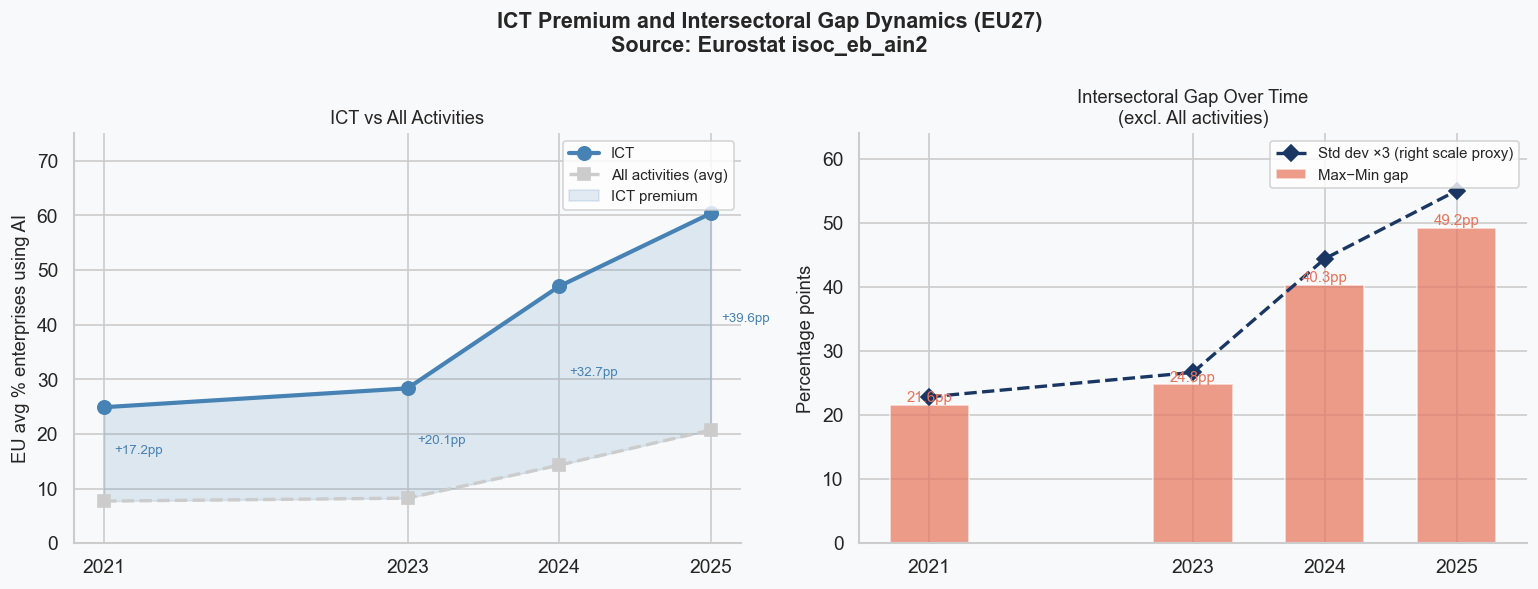


ICT premium over all-sector average:
  2021: ICT 24.9%  |  All 7.7%  |  premium +17.2 pp
  2023: ICT 28.3%  |  All 8.2%  |  premium +20.1 pp
  2024: ICT 47.0%  |  All 14.3%  |  premium +32.7 pp
  2025: ICT 60.4%  |  All 20.7%  |  premium +39.6 pp


In [83]:
# ── S5 — ICT premium and intersectoral gap convergence/divergence over time ───
ict_label = "Information & Communication"
all_label = "All activities"

ict_trend = df_sector[df_sector["sector"] == ict_label].groupby("yr")["value"].mean()
all_trend = df_sector[df_sector["sector"] == all_label].groupby("yr")["value"].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor=BG)
fig.suptitle("ICT Premium and Intersectoral Gap Dynamics (EU27)\nSource: Eurostat isoc_eb_ain2",
             fontsize=13, fontweight="bold")

# Left: ICT vs All activities trend
ax = axes[0]
ax.set_facecolor(BG)
ax.plot(ict_trend.index, ict_trend.values, color=C_BLUE, marker="o", lw=2.5,
        markersize=8, label="ICT")
ax.plot(all_trend.index, all_trend.values, color=C_GREY, marker="s", lw=2,
        markersize=7, linestyle="--", label="All activities (avg)")
ax.fill_between(ict_trend.index, all_trend.reindex(ict_trend.index),
                ict_trend.values, alpha=0.15, color=C_BLUE, label="ICT premium")
for yr in ict_trend.index:
    if yr in all_trend.index:
        premium = ict_trend[yr] - all_trend[yr]
        mid = (ict_trend[yr] + all_trend[yr]) / 2
        ax.annotate(f"+{premium:.1f}pp", (yr, mid),
                    textcoords="offset points", xytext=(6, 0),
                    fontsize=8, color=C_BLUE)
ax.set_xticks(YEARS)
ax.set_ylabel("EU avg % enterprises using AI", fontsize=11)
ax.set_title("ICT vs All Activities", fontsize=11)
ax.legend(fontsize=9)
ax.set_ylim(0, 75)
ax.spines[["top", "right"]].set_visible(False)

# Right: sector spread (max − min) over time = convergence/divergence
ax2 = axes[1]
ax2.set_facecolor(BG)
gap_over_time = {}
std_over_time = {}
for yr in YEARS:
    sub = df_sector[df_sector["yr"] == yr].groupby("sector")["value"].mean()
    excl_all = sub.drop(all_label, errors="ignore")
    gap_over_time[yr] = excl_all.max() - excl_all.min()
    std_over_time[yr] = excl_all.std()

gap_s = pd.Series(gap_over_time)
std_s = pd.Series(std_over_time)

ax2.bar(gap_s.index, gap_s.values, color=C_ORANGE, alpha=0.7, width=0.6, label="Max−Min gap")
ax2.plot(std_s.index, std_s.values * 3, color=C_NAVY, marker="D", lw=2,
         markersize=7, linestyle="--", label="Std dev ×3 (right scale proxy)")
for yr, v in gap_s.items():
    ax2.text(yr, v + 0.5, f"{v:.1f}pp", ha="center", fontsize=9, color=C_ORANGE)
ax2.set_xticks(YEARS)
ax2.set_ylabel("Percentage points", fontsize=11)
ax2.set_title("Intersectoral Gap Over Time\n(excl. All activities)", fontsize=11)
ax2.legend(fontsize=9)
ax2.set_ylim(0, gap_s.max() * 1.3)
ax2.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

print("\nICT premium over all-sector average:")
for yr in YEARS:
    if yr in ict_trend.index and yr in all_trend.index:
        print(f"  {yr}: ICT {ict_trend[yr]:.1f}%  |  All {all_trend[yr]:.1f}%  |  premium +{ict_trend[yr]-all_trend[yr]:.1f} pp")

---

## 2.2 Understanding the Intersectoral Gap

The five charts above establish the basic facts: ICT leads at 60%, Construction trails at 11%, and the distance between the two has been growing every year. The natural question is *why*. This section moves from description to explanation, combining two additional quantitative tests (S6–S9) with the theoretical and empirical literature on technology diffusion across industries.

### What the data already show

Three findings from S1–S5 set up the explanatory problem:

1. **The gap is large and structural.** The intersectoral spread (max minus min, excluding the aggregate) stood at 49 percentage points in 2025 — roughly the same distance as between Romania and Denmark at the country level. This is not noise; it reflects a deep asymmetry in how different parts of the economy relate to digital technology.

2. **ICT is not just ahead — it is accelerating away.** The ICT premium over the cross-sector average doubled from +17 pp in 2021 to +40 pp in 2025. No other sector shows anything close to this trajectory.

3. **Country heterogeneity is largest precisely in the leading sector.** The standard deviation of adoption rates *within* ICT (14.5 pp) exceeds that of any lagging sector. This tells us that the ICT advantage is not automatic: it depends on country-level conditions that some EU members have built and others have not.

### Four mechanisms from the economic literature

**S6–S9 below test these mechanisms quantitatively. The theoretical background is summarised here.**

---

#### Mechanism 1 — Task codifiability
*(McKinsey Global Institute, 2018; Acemoglu, Autor, Hazell & Restrepo, 2022)*

AI systems learn from structured digital records. In ICT and professional services, most productive activity already generates such records: code repositories, legal documents, financial data, client communications. An AI model can observe these inputs, identify patterns, and produce usable outputs with relatively modest additional investment. In construction and accommodation, the core operative unit is physical — a building site, a kitchen, a delivery route. Encoding these activities as machine-readable training data requires expensive sensing infrastructure (IoT, computer vision, geospatial systems) that most firms in these sectors do not possess. McKinsey (2018) estimated that 70–80% of tasks in ICT are technically susceptible to AI automation, against 30–45% in construction. The gap in *adoption* is, to a significant degree, a reflection of this gap in *technical feasibility*.

---

#### Mechanism 2 — Complementary intangible assets
*(Brynjolfsson, Rock & Syverson, American Economic Journal: Macroeconomics, 2021)*

AI is a general-purpose technology: like electricity or the internet, it creates value not by itself but in combination with complementary investments — proprietary data pipelines, digitally redesigned workflows, and organisational processes built around AI outputs. ICT firms have been accumulating these intangibles for two decades. A construction SME with no internal data infrastructure, no dedicated IT function, and workflows built around subcontractor coordination faces a far steeper J-curve before any AI investment generates a positive return. Brynjolfsson et al. formalise this insight and show that the intangible capital gap is self-reinforcing: early adopters generate productivity gains that fund further investment, while late movers fall further behind. This mechanism explains why the gap widens even as aggregate adoption rises.

---

#### Mechanism 3 — Workforce digital skill intensity
*(OECD Digital Economy Outlook, 2024; European Commission DESI, 2023)*

Deploying AI requires workers who can configure, interpret, and oversee AI systems — a skill profile concentrated in STEM graduates, data engineers, and digitally literate managers. The ICT sector employs these workers as its core input. Accommodation, food service, and construction employ predominantly low-skilled workers in routine physical roles. Even if AI tools were available at zero cost, the human capital needed to deploy them productively would still be missing. The DESI 2023 report identifies workforce digital skills as the single strongest country-level predictor of enterprise AI adoption, and the OECD (2024) documents the same pattern at the sectoral level.

---

#### Mechanism 4 — Firm size composition within sectors
*(Calvino, Criscuolo, Marcolin & Squicciarini, OECD STI Working Paper, 2018; ISTAT, 2023)*

Large firms adopt AI at rates 2–3× higher than SMEs — in the EU27, 55% of large enterprises used AI in 2025, against 14% of small ones. ICT and professional services are dominated by large firms with dedicated IT departments, legal teams, and capacity to absorb technology risk. Construction, accommodation, and food are among the most atomised sectors in the European economy, populated by micro-enterprises with fewer than ten employees. Much of what appears as a "sector effect" in the aggregate data is, in reality, a disguised "firm size effect": lagging sectors lag partly because they are structurally composed of the firm types that adopt AI last in every sector. Italy is particularly exposed to this mechanism, given the exceptionally high share of micro-firms in its physical-economy sectors.

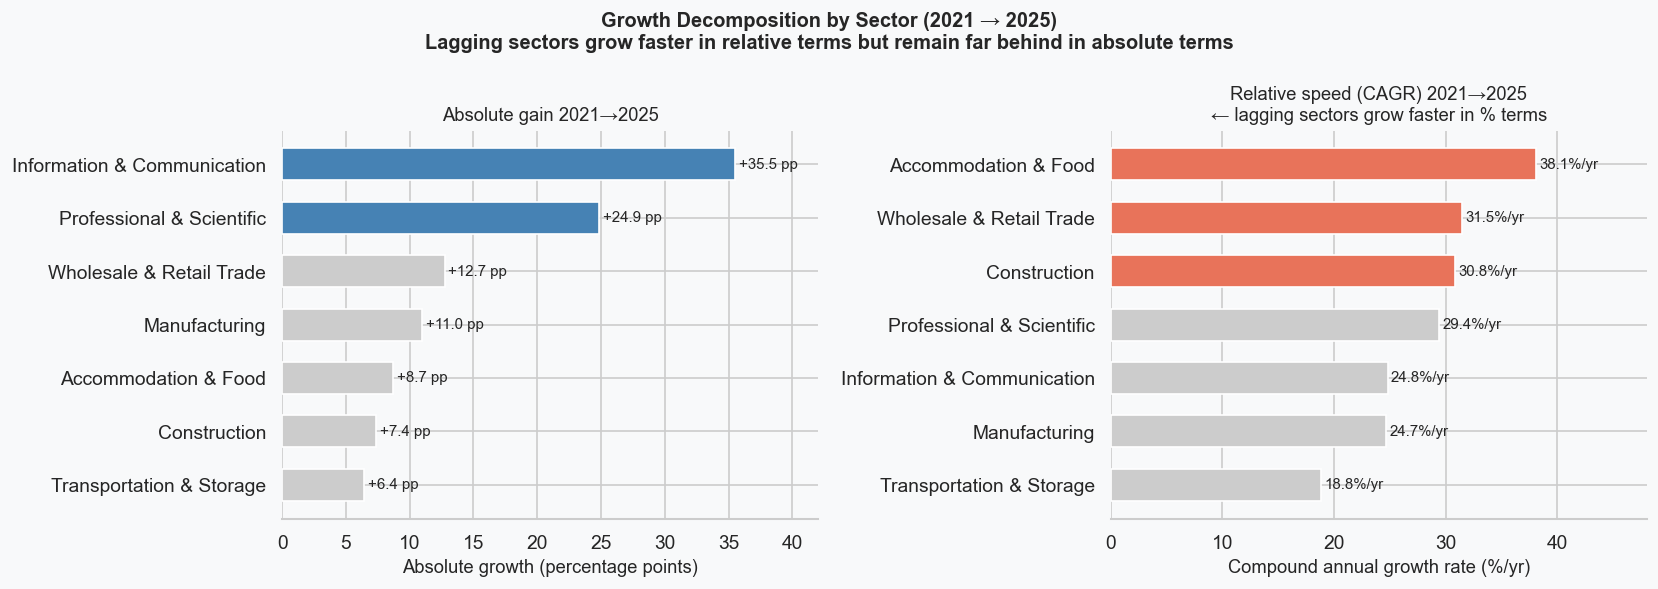

Key insight: Accommodation (+38% CAGR) and Construction (+31% CAGR) grow faster in relative
terms than ICT (+25% CAGR), but start from such a low base (3-4% in 2021) that the absolute
gap still widens: ICT went from +17 pp above average to +36 pp above average in 4 years.


In [84]:
# ── S6 — Growth decomposition: absolute pp vs relative CAGR ──────────────────
# Paradox: lagging sectors have HIGHER relative CAGR but LOWER absolute growth
# → absolute gap still widens even while relative gap may narrow

records = []
for s in df_sector["sector"].unique():
    sub = df_sector[df_sector["sector"] == s].groupby("yr")["value"].mean()
    if 2021 in sub.index and 2025 in sub.index and sub[2021] > 0:
        abs_growth = sub[2025] - sub[2021]
        cagr = ((sub[2025] / sub[2021]) ** (1/4) - 1) * 100
        records.append({"sector": s, "val_2021": sub[2021], "val_2025": sub[2025],
                         "abs_growth": abs_growth, "cagr": cagr})
growth_df = pd.DataFrame(records).sort_values("val_2025", ascending=False)
growth_df = growth_df[growth_df["sector"] != "All activities"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG)
fig.suptitle("Growth Decomposition by Sector (2021 → 2025)\n"
             "Lagging sectors grow faster in relative terms but remain far behind in absolute terms",
             fontsize=12, fontweight="bold")

# Left: absolute growth (pp)
ax = axes[0]
ax.set_facecolor(BG)
order_abs = growth_df.sort_values("abs_growth", ascending=True)
cols = [C_BLUE if "Information" in s or "Professional" in s else C_GREY for s in order_abs["sector"]]
ax.barh(order_abs["sector"], order_abs["abs_growth"], color=cols, edgecolor="white", height=0.6)
for i, (_, row) in enumerate(order_abs.iterrows()):
    ax.text(row["abs_growth"] + 0.3, i, f"+{row['abs_growth']:.1f} pp", va="center", fontsize=9)
ax.set_xlabel("Absolute growth (percentage points)", fontsize=11)
ax.set_title("Absolute gain 2021→2025", fontsize=11)
ax.set_xlim(0, 42)
ax.spines[["top", "right", "left"]].set_visible(False)

# Right: CAGR %
ax2 = axes[1]
ax2.set_facecolor(BG)
order_cagr = growth_df.sort_values("cagr", ascending=True)
cols2 = [C_ORANGE if "Accommodation" in s or "Construction" in s or "Wholesale" in s else C_GREY
         for s in order_cagr["sector"]]
ax2.barh(order_cagr["sector"], order_cagr["cagr"], color=cols2, edgecolor="white", height=0.6)
for i, (_, row) in enumerate(order_cagr.iterrows()):
    ax2.text(row["cagr"] + 0.3, i, f"{row['cagr']:.1f}%/yr", va="center", fontsize=9)
ax2.set_xlabel("Compound annual growth rate (%/yr)", fontsize=11)
ax2.set_title("Relative speed (CAGR) 2021→2025\n← lagging sectors grow faster in % terms", fontsize=11)
ax2.set_xlim(0, 48)
ax2.spines[["top", "right", "left"]].set_visible(False)

plt.tight_layout()
plt.show()

print("Key insight: Accommodation (+38% CAGR) and Construction (+31% CAGR) grow faster in relative")
print("terms than ICT (+25% CAGR), but start from such a low base (3-4% in 2021) that the absolute")
print("gap still widens: ICT went from +17 pp above average to +36 pp above average in 4 years.")

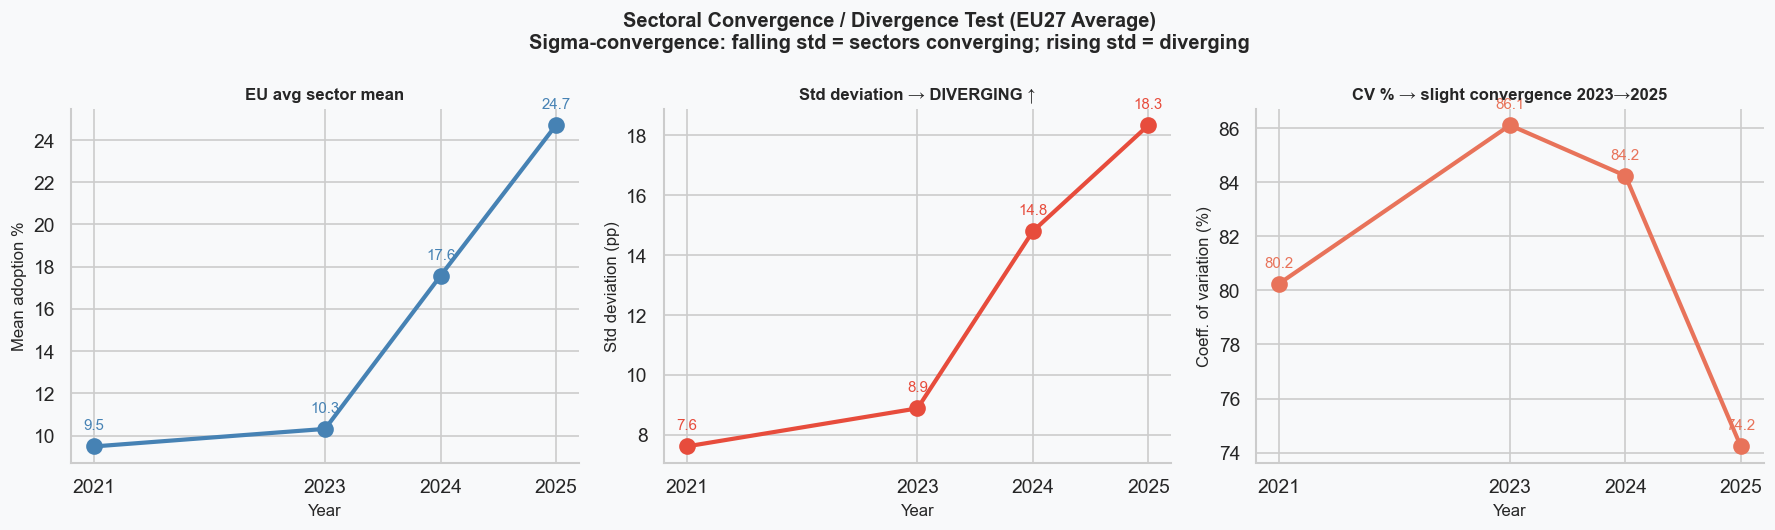

Interpretation:
  • Std deviation RISES from 7.6 (2021) to 18.3 (2025) → absolute DIVERGENCE
  • CV PEAKS in 2023 (86%) then FALLS to 74% → relative convergence starts only in 2024-25
  • Conclusion: in absolute pp terms, sectors are DIVERGING. The ICT sector
    accelerates faster than others can catch up, widening the digital divide.


In [85]:
# ── S7 — Convergence vs divergence: CV and Sigma-convergence over time ────────
# Sigma-convergence: std of sectoral adoption declining → convergence
# If std grows → sectors are diverging

cv_records, std_records, mean_records = [], [], []
for yr in YEARS:
    sub = df_sector[(df_sector["yr"] == yr) & (df_sector["sector"] != "All activities")]\
          .groupby("sector")["value"].mean()
    cv_records.append({"yr": yr, "cv": sub.std() / sub.mean() * 100})
    std_records.append({"yr": yr, "std": sub.std()})
    mean_records.append({"yr": yr, "mean": sub.mean()})

cv_df   = pd.DataFrame(cv_records).set_index("yr")
std_df  = pd.DataFrame(std_records).set_index("yr")
mean_df = pd.DataFrame(mean_records).set_index("yr")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), facecolor=BG)
fig.suptitle("Sectoral Convergence / Divergence Test (EU27 Average)\n"
             "Sigma-convergence: falling std = sectors converging; rising std = diverging",
             fontsize=12, fontweight="bold")

for ax_i, (df_plot, label, color, title) in enumerate([
    (mean_df, "Mean adoption %", C_BLUE, "EU avg sector mean"),
    (std_df,  "Std deviation (pp)", C_RED, "Std deviation → DIVERGING ↑"),
    (cv_df,   "Coeff. of variation (%)", C_ORANGE, "CV % → slight convergence 2023→2025"),
]):
    ax = axes[ax_i]
    ax.set_facecolor(BG)
    ax.plot(df_plot.index, df_plot.iloc[:, 0], color=color, marker="o",
            markersize=9, linewidth=2.5)
    for yr, val in zip(df_plot.index, df_plot.iloc[:, 0]):
        ax.annotate(f"{val:.1f}", (yr, val), textcoords="offset points",
                    xytext=(0, 10), ha="center", fontsize=9, color=color)
    ax.set_xticks(YEARS)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xlabel("Year", fontsize=10)
    ax.set_ylabel(label, fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

print("Interpretation:")
print("  • Std deviation RISES from 7.6 (2021) to 18.3 (2025) → absolute DIVERGENCE")
print("  • CV PEAKS in 2023 (86%) then FALLS to 74% → relative convergence starts only in 2024-25")
print("  • Conclusion: in absolute pp terms, sectors are DIVERGING. The ICT sector")
print("    accelerates faster than others can catch up, widening the digital divide.")

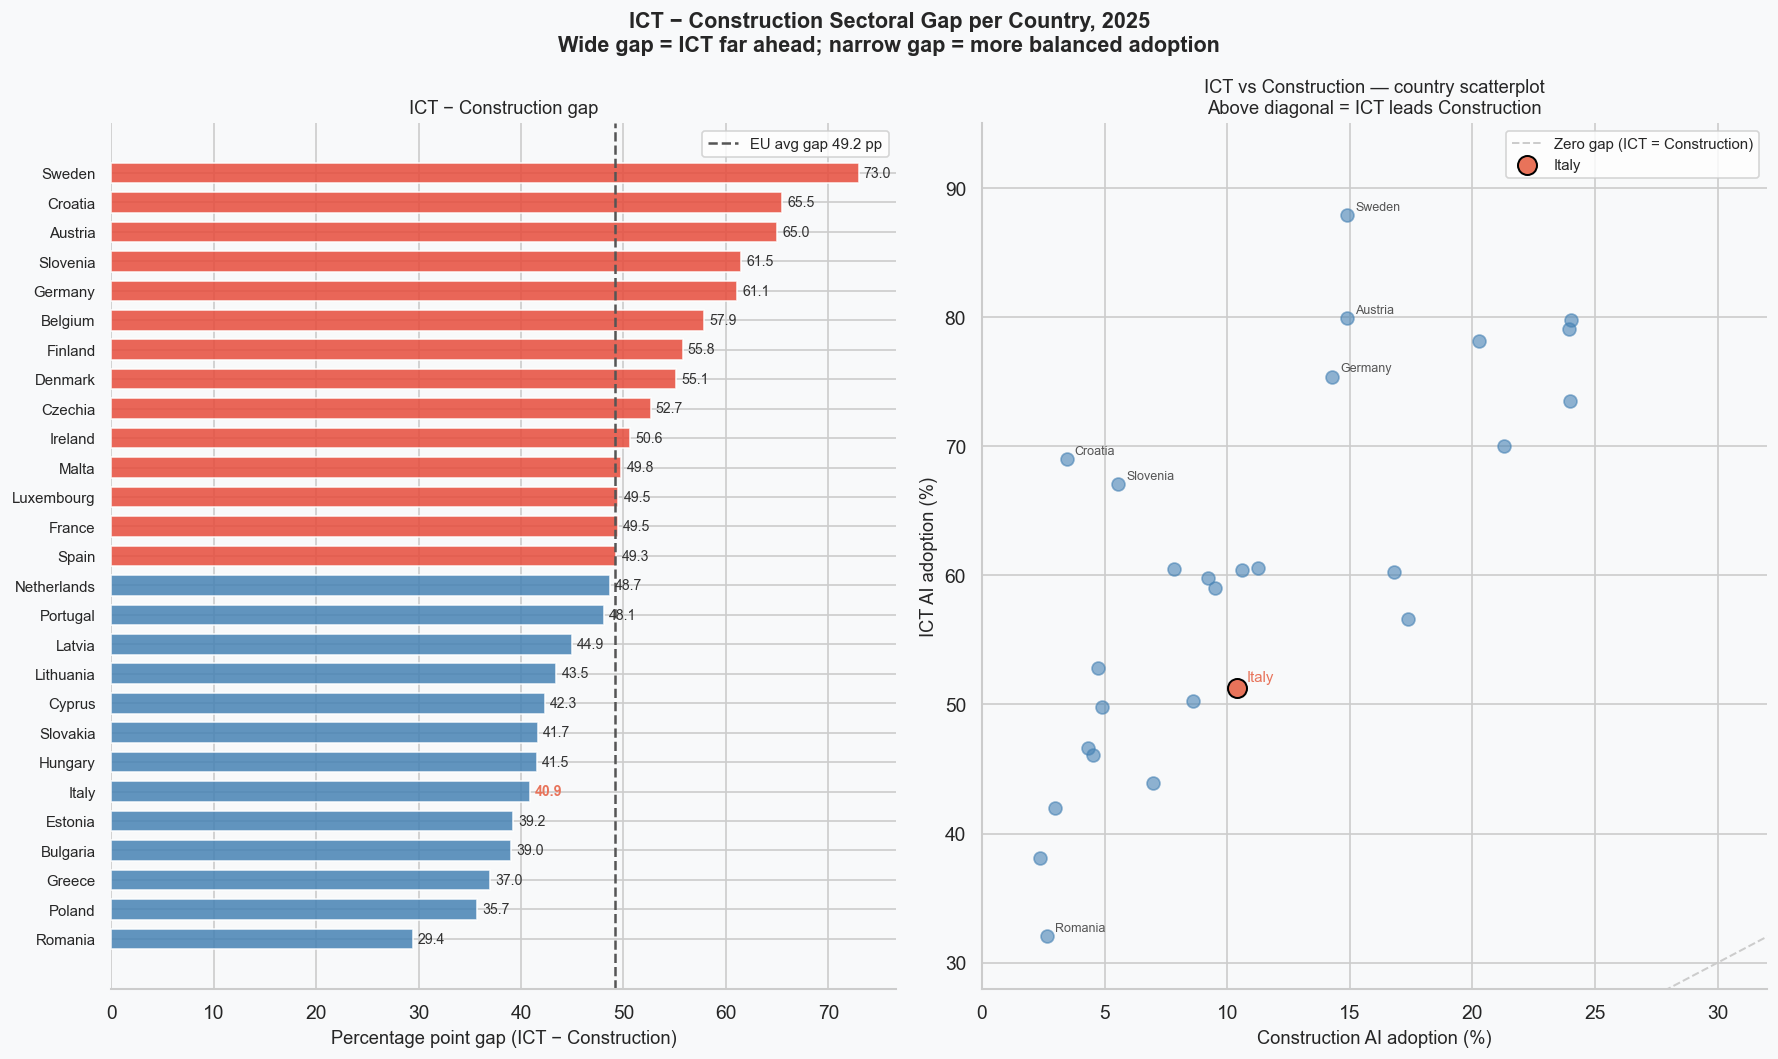


Country with widest ICT-Construction gap : Sweden (73.0 pp)
Country with narrowest ICT-Construction gap: Romania (29.4 pp)
Italy ICT-Construction gap: 40.9 pp  (EU avg: 49.2 pp)


In [86]:
# ── S8 — ICT−Construction gap per country (2025): who has the widest divide? ──
ict = (df_sector[(df_sector["sector"] == "Information & Communication") & (df_sector["yr"] == 2025)]
       .set_index("country")["value"])
con = (df_sector[(df_sector["sector"] == "Construction") & (df_sector["yr"] == 2025)]
       .set_index("country")["value"])
gap_ic = (ict - con).dropna().sort_values(ascending=True)

# also compute overall AI adoption for colour coding
all_2025 = (df_sector[(df_sector["sector"] == "All activities") & (df_sector["yr"] == 2025)]
            .set_index("country")["value"])

fig, axes = plt.subplots(1, 2, figsize=(15, 9), facecolor=BG)
fig.suptitle("ICT − Construction Sectoral Gap per Country, 2025\n"
             "Wide gap = ICT far ahead; narrow gap = more balanced adoption",
             fontsize=13, fontweight="bold")

# Left: gap bar
ax = axes[0]
ax.set_facecolor(BG)
cols_gap = [C_RED if v > gap_ic.mean() else C_BLUE for v in gap_ic]
ax.barh(gap_ic.index, gap_ic.values, color=cols_gap, edgecolor="white", height=0.7, alpha=0.85)
ax.axvline(gap_ic.mean(), color="#555", lw=1.5, ls="--",
           label=f"EU avg gap {gap_ic.mean():.1f} pp")
for i, (c, v) in enumerate(gap_ic.items()):
    col = "#333" if c != "Italy" else C_ORANGE
    weight = "bold" if c == "Italy" else "normal"
    ax.text(v + 0.5, i, f"{v:.1f}", va="center", fontsize=8.5,
            color=col, fontweight=weight)
ax.set_xlabel("Percentage point gap (ICT − Construction)", fontsize=11)
ax.set_title("ICT − Construction gap", fontsize=11)
ax.legend(fontsize=9)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", labelsize=9)

# Right: scatter ICT vs Construction
ax2 = axes[1]
ax2.set_facecolor(BG)
common = ict.index.intersection(con.index)
ax2.scatter(con.reindex(common), ict.reindex(common), color=C_STEEL, alpha=0.6, s=60, zorder=3)
# 45° line = zero gap
lims = [0, 92]
ax2.plot(lims, lims, color="#ccc", lw=1.2, ls="--", label="Zero gap (ICT = Construction)")
# highlight Italy
if "Italy" in common:
    ax2.scatter(con["Italy"], ict["Italy"], color=C_ORANGE, s=130, zorder=5,
                edgecolors="black", linewidth=1.2, label="Italy")
    ax2.annotate("Italy", (con["Italy"], ict["Italy"]),
                 textcoords="offset points", xytext=(6, 4), fontsize=9, color=C_ORANGE)
# label outliers
for c in common:
    if gap_ic.get(c, 0) > 60 or gap_ic.get(c, 0) < 35:
        ax2.annotate(c, (con[c], ict[c]), textcoords="offset points",
                     xytext=(5, 3), fontsize=7.5, color="#555")
ax2.set_xlabel("Construction AI adoption (%)", fontsize=11)
ax2.set_ylabel("ICT AI adoption (%)", fontsize=11)
ax2.set_title("ICT vs Construction — country scatterplot\nAbove diagonal = ICT leads Construction", fontsize=11)
ax2.legend(fontsize=9)
ax2.set_xlim(0, 32)
ax2.set_ylim(28, 95)
ax2.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

print(f"\nCountry with widest ICT-Construction gap : {gap_ic.idxmax()} ({gap_ic.max():.1f} pp)")
print(f"Country with narrowest ICT-Construction gap: {gap_ic.idxmin()} ({gap_ic.min():.1f} pp)")
print(f"Italy ICT-Construction gap: {gap_ic.get('Italy', float('nan')):.1f} pp  (EU avg: {gap_ic.mean():.1f} pp)")

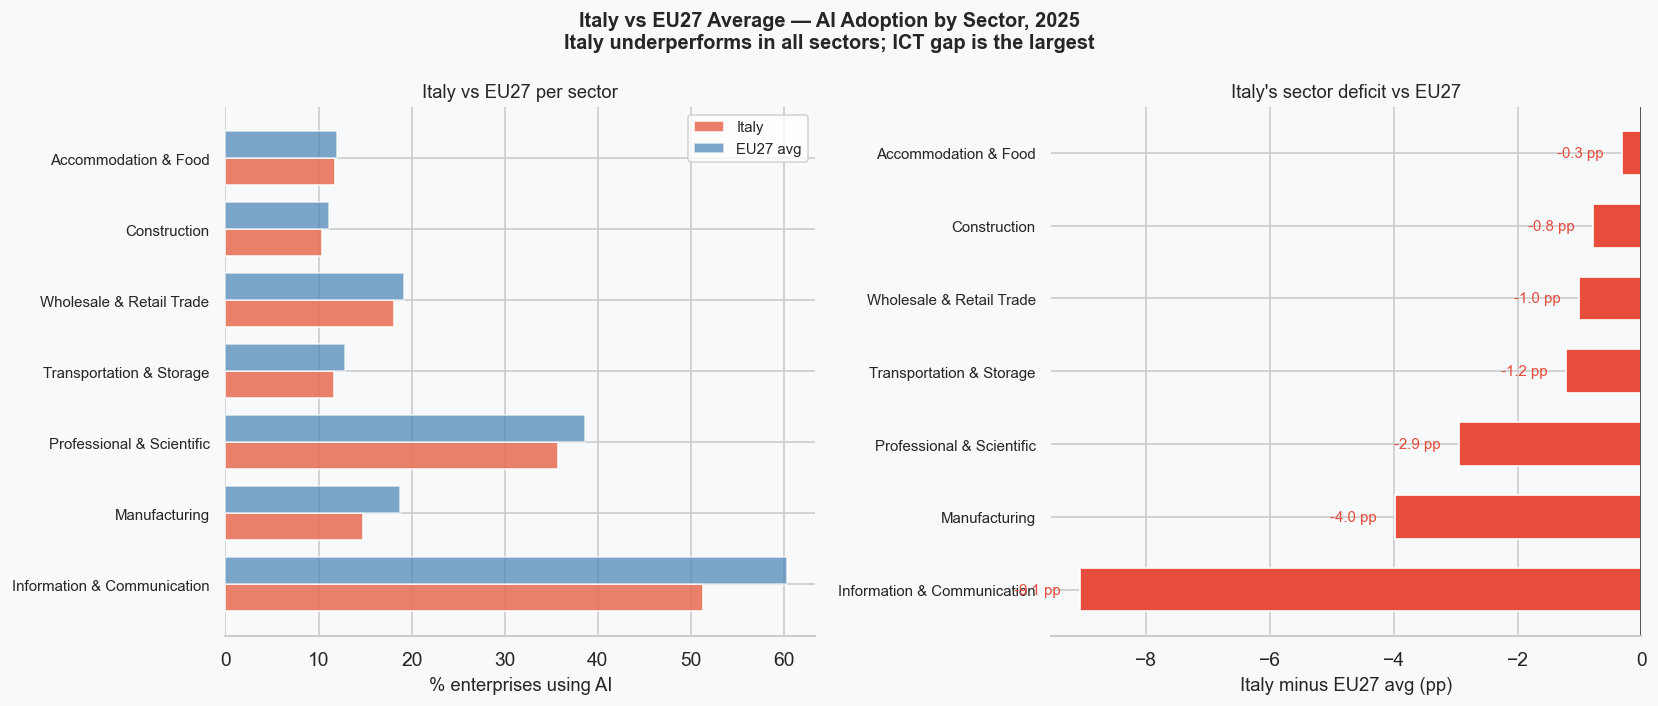

Italy's sectoral deficit vs EU27 (2025):
  Information & Communication         IT=51.3%  EU=60.4%  Δ=-9.1 pp
  Manufacturing                       IT=14.7%  EU=18.7%  Δ=-4.0 pp
  Professional & Scientific           IT=35.7%  EU=38.7%  Δ=-2.9 pp
  Transportation & Storage            IT=11.6%  EU=12.8%  Δ=-1.2 pp
  Wholesale & Retail Trade            IT=18.1%  EU=19.1%  Δ=-1.0 pp
  Construction                        IT=10.4%  EU=11.2%  Δ=-0.8 pp
  Accommodation & Food                IT=11.7%  EU=12.0%  Δ=-0.3 pp

Italy underperforms in ALL sectors. Largest gap: ICT (-9.1 pp)
But in physical-economy sectors (Construction, Transport, Food) Italy is nearly at EU level.
→ Italy's problem is mainly in ICT and Professional services, not in traditional sectors.


In [87]:
# ── S9 — Italy vs EU27: sector-by-sector deficit ─────────────────────────────
eu_avg_sec = df_sector[df_sector["yr"] == 2025].groupby("sector")["value"].mean()
it_sec_25  = (df_sector[(df_sector["country"] == "Italy") & (df_sector["yr"] == 2025)]
              .set_index("sector")["value"])

sectors_plot = [s for s in eu_avg_sec.index if s != "All activities"]
it_vals  = [it_sec_25.get(s, np.nan) for s in sectors_plot]
eu_vals  = [eu_avg_sec[s] for s in sectors_plot]
diffs    = [i - e for i, e in zip(it_vals, eu_vals)]
order_idx = np.argsort(diffs)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor=BG)
fig.suptitle("Italy vs EU27 Average — AI Adoption by Sector, 2025\n"
             "Italy underperforms in all sectors; ICT gap is the largest",
             fontsize=12, fontweight="bold")

# Left: side-by-side bars Italy vs EU
ax = axes[0]
ax.set_facecolor(BG)
x = np.arange(len(sectors_plot))
w = 0.38
sorted_sectors = [sectors_plot[i] for i in order_idx]
it_s = [it_vals[i] for i in order_idx]
eu_s = [eu_vals[i] for i in order_idx]
ax.barh(x - w/2, it_s, w, label="Italy", color=C_ORANGE, edgecolor="white", alpha=0.9)
ax.barh(x + w/2, eu_s, w, label="EU27 avg", color=C_STEEL, edgecolor="white", alpha=0.7)
ax.set_yticks(x)
ax.set_yticklabels(sorted_sectors, fontsize=9)
ax.set_xlabel("% enterprises using AI", fontsize=11)
ax.set_title("Italy vs EU27 per sector", fontsize=11)
ax.legend(fontsize=9)
ax.spines[["top", "right", "left"]].set_visible(False)

# Right: deficit bar (Italy − EU)
ax2 = axes[1]
ax2.set_facecolor(BG)
sorted_diffs = [diffs[i] for i in order_idx]
cols_d = [C_RED if d < 0 else C_GREEN for d in sorted_diffs]
ax2.barh(x, sorted_diffs, color=cols_d, edgecolor="white", height=0.6)
ax2.axvline(0, color="#555", lw=1.2)
for i, d in enumerate(sorted_diffs):
    ax2.text(d - 0.3 if d < 0 else d + 0.2, i, f"{d:+.1f} pp",
             va="center", ha="right" if d < 0 else "left", fontsize=9,
             color=C_RED if d < 0 else C_GREEN)
ax2.set_yticks(x)
ax2.set_yticklabels(sorted_sectors, fontsize=9)
ax2.set_xlabel("Italy minus EU27 avg (pp)", fontsize=11)
ax2.set_title("Italy's sector deficit vs EU27", fontsize=11)
ax2.spines[["top", "right", "left"]].set_visible(False)

plt.tight_layout()
plt.show()

print("Italy's sectoral deficit vs EU27 (2025):")
for s, d in sorted(zip(sectors_plot, diffs), key=lambda x: x[1]):
    print(f"  {s:<35} IT={it_sec_25.get(s, float('nan')):.1f}%  EU={eu_avg_sec[s]:.1f}%  Δ={d:+.1f} pp")
print(f"\nItaly underperforms in ALL sectors. Largest gap: ICT (-9.1 pp)")
print("But in physical-economy sectors (Construction, Transport, Food) Italy is nearly at EU level.")
print("→ Italy's problem is mainly in ICT and Professional services, not in traditional sectors.")

---

## 2.3 Summary of Findings and Policy Implications

### What the quantitative analysis shows

**S6 — The growth paradox.** Lagging sectors post higher relative growth rates: Accommodation grew at +38%/year (CAGR) between 2021 and 2025, Construction at +31%, both faster than ICT at +25%. Yet because they started from near-zero bases (3–4% in 2021), their absolute gains are tiny compared to ICT's +35.5 percentage point increase in four years. The absolute gap is widening even as the relative gap starts to close — a textbook illustration of the base-rate problem in technology diffusion.

**S7 — Sigma-divergence confirmed.** The standard deviation of adoption rates across sectors rose from 7.6 pp in 2021 to 18.3 pp in 2025, a clear signal of sigma-divergence. The coefficient of variation peaked at 86% in 2023 and then fell back to 74% by 2025, hinting at the early stages of relative convergence — but not enough to reverse the absolute spread. The pattern is consistent with the theoretical prediction of Brynjolfsson et al. (2021): technology diffusion through a J-curve, where early adopters pull ahead before the rest of the economy catches up.

**S8 — The ICT–Construction gap is universal but unequal.** Every EU27 country shows ICT adoption far above construction, with the gap ranging from 29 pp (Romania) to 73 pp (Sweden). Countries with high overall AI adoption tend to have a *wider* ICT–Construction gap, not a narrower one — suggesting that digital leaders advance primarily through their ICT sector rather than through a broad-based diffusion across all activities.

**S9 — Italy's structural weakness is sector-specific.** Italy underperforms the EU average in every sector, but the distribution of the deficit is revealing. The largest gap is in ICT (−9.1 pp), the sector where AI adoption is highest and productivity returns are largest. In contrast, Italy is nearly at EU parity in Construction (−0.8 pp), Accommodation (−0.3 pp), and Transport (−1.2 pp). Italy's aggregate AI adoption shortfall is not driven by being especially bad at traditional sectors — it is driven by having a relatively small and underdeveloped ICT sector compared to northern European peers.

---

### Policy implications

The four mechanisms identified above have direct implications for policy, and they point in different directions depending on whether the goal is to raise aggregate adoption or to reduce intersectoral inequality.

**If the goal is speed of adoption:** investment should concentrate in ICT and professional services, where returns are immediate and complementary assets already exist. This is the implicit strategy of digital-leader countries such as Denmark, Finland, and Sweden.

**If the goal is reducing inequality:** policy must address the structural barriers that prevent physical-economy sectors from catching up. These include: access to affordable cloud-based AI tools designed for SMEs; sector-specific digital training programmes for workers in construction and hospitality; support for industry-wide data-sharing platforms that allow firms with no internal data infrastructure to access usable AI inputs; and investment in digital public infrastructure (connectivity, e-government) that reduces the marginal cost of adoption for small firms.

**For Italy specifically:** the priority is not to fix traditional sectors — they are already close to the EU average. The priority is to strengthen the ICT and professional services ecosystem, which is the weakest point in Italy's digital economy relative to the EU. This means investing in STEM education, R&D tax incentives for tech firms, and targeted policies to scale up Italy's digital-native companies.

---

### Literature

| Authors | Title | Venue | Year |
|---------|-------|-------|------|
| McKinsey Global Institute | *Notes from the AI Frontier: Modeling the Impact of AI on the World Economy* | MGI Report | 2018 |
| Calvino, Criscuolo, Marcolin & Squicciarini | *A Taxonomy of Digital Intensive Sectors* | OECD STI Working Paper 2018/14 | 2018 |
| Brynjolfsson, Rock & Syverson | *The Productivity J-Curve: How Intangibles Complement General Purpose Technologies* | American Economic Journal: Macroeconomics | 2021 |
| Acemoglu, Autor, Hazell & Restrepo | *Artificial Intelligence and Jobs: Evidence from Online Vacancies* | Journal of Labor Economics | 2022 |
| European Commission, DG CONNECT | *Digital Economy and Society Index (DESI) 2023* | EU Commission Report | 2023 |
| OECD | *OECD Digital Economy Outlook 2024* | OECD Publishing | 2024 |
| McKinsey & Company | *The State of AI 2024* | McKinsey Global Survey | 2024 |
| Eurostat | *Artificial Intelligence in Enterprises — Statistics Explained* | Eurostat, ec.europa.eu | 2024 |
| ISTAT | *Indagine sull'uso delle tecnologie dell'informazione e della comunicazione nelle imprese* | ISTAT Annual ICT Survey | 2023–24 |